# S2 Coursework DRAFT

## Question 1: Accident data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
mining_data = np.loadtxt(os.path.join('data','coal_mining_accident_data.dat'))
flattened_data = np.ndarray.flatten(mining_data, order="C")
flattened_data_cumulative = np.copy(flattened_data)

total_period = 40550
total_events = 191

for i in range(len(flattened_data)-1):
    flattened_data_cumulative[i+1:] += flattened_data[i]
number_of_accidents = np.arange(0, len(flattened_data_cumulative), 1)

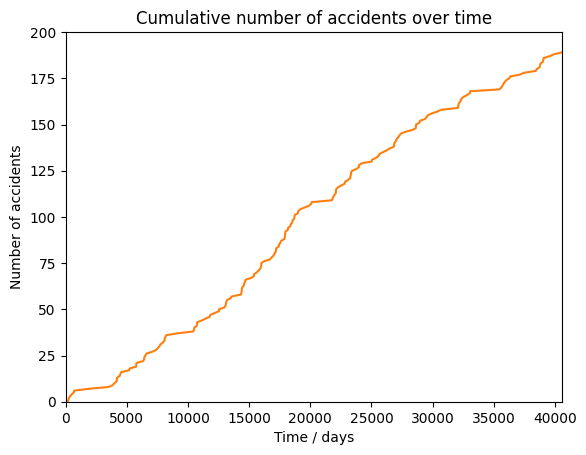

In [3]:
plt.plot(flattened_data_cumulative, number_of_accidents, color="tab:orange")
plt.xlabel("Time / days")
plt.ylabel("Number of accidents")
plt.title("Cumulative number of accidents over time")
plt.xlim(0,40550)
plt.ylim(0,200)
plt.show()

In [4]:
mean_rate = total_events / (total_period)
print(f"Mean rate of accidents: {mean_rate:.4f} per day")
mean_rate_year = number_of_accidents[-1] / (total_period / 365) # Convert total period from years to days
print(f"Mean rate of accidents: {mean_rate_year:.2f} per year")

Mean rate of accidents: 0.0047 per day
Mean rate of accidents: 1.70 per year


## Question 2: Priors

### (a)

(4,)
[ 7869.45892267  8234.18116059 23954.71383866 28139.24961026]
(4,)
[13528.18432315 21327.27753656 25496.71024835 28177.91718096]


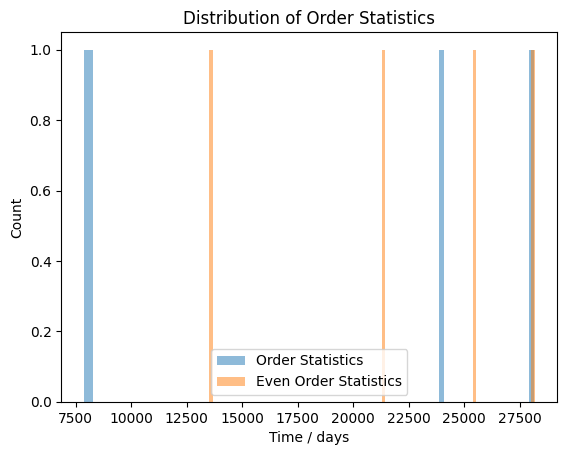

In [5]:
from scipy import special

def gamma(x, alpha, beta):
    pdf = (beta ** alpha) * np.exp(-beta * x) / special.gamma(alpha)
    return pdf

k = 4
order_statistics = np.sort(np.random.uniform(0, total_period, k))
print(np.shape(order_statistics))
print(order_statistics)
even_order_statistics = np.sort(np.random.uniform(0, total_period, 2 * k + 1))[1:-1:2]
print(np.shape(even_order_statistics))
print(even_order_statistics)

plt.hist(order_statistics, bins=100, density=False, alpha=0.5, label='Order Statistics')
plt.hist(even_order_statistics, bins=100, density=False, alpha=0.5, label='Even Order Statistics')
plt.xlabel("Time / days")
plt.ylabel("Count")
plt.title("Distribution of Order Statistics")
plt.legend()
plt.show()

## Question 3: The constant rate model

### (a)

The prior on $h_0$ is 

\begin{equation}
    \pi(h_0|M_0)=\beta^\alpha\exp(-\beta h)/\Gamma(\alpha),
\end{equation}

where $\alpha=1$, $\beta=200\;\text{days}$. In the constant rate case, the log-likelihood is simply

\begin{equation}
    \log\mathcal{L}(\{I_i\}|h_0,M_0)=N\log h_0-h_0L.
\end{equation}

The posterior on $h_0$ is thus

\begin{equation}
    P(h_0|\{I_i\}, M_0)=200h_0^N\exp(-h_0(200+L)).
\end{equation}

In [6]:
alpha = 1
beta = 200

def constant_rate_prior(h, alpha, beta):
    return beta ** alpha * np.exp(-beta * h) / special.gamma(alpha)

def log_constant_rate_prior(h, alpha, beta):
    return alpha * np.log(beta) - beta * h - special.gammaln(alpha)

def constant_rate_likelihood(h):
    return h ** total_events * np.exp(-h * total_period)

def log_constant_rate_likelihood(h):
    return total_events * np.log(h) - h * total_period

def constant_rate_posterior(h, alpha, beta):
    return constant_rate_prior(h, alpha, beta) * constant_rate_likelihood(h) * model_prior(0)

def log_constant_rate_posterior(h, alpha, beta):
    return log_constant_rate_prior(h, alpha, beta) + log_constant_rate_likelihood(h)

/tmp/ipykernel_14259/769097394.py:14: RuntimeWarning: divide by zero encountered in log
  return total_events * np.log(h) - h * total_period


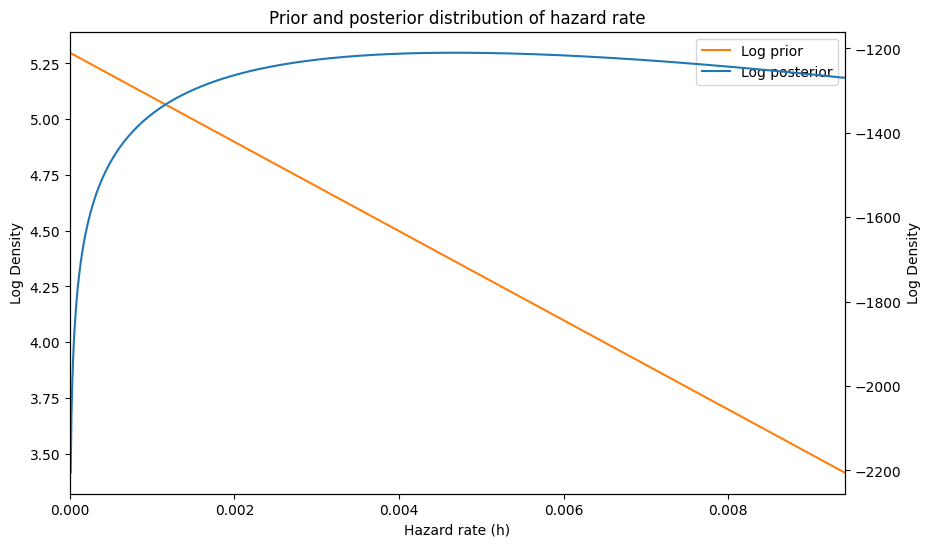

In [7]:
h_values = np.linspace(0, 191 * 2 / 40550, 1000)
log_posterior_values = log_constant_rate_posterior(h_values, alpha, beta)
log_prior_values = log_constant_rate_prior(h_values, alpha, beta)

fig, ax = plt.subplots(figsize=(10, 6))
ax2 = ax.twinx()
p1 = ax.plot(h_values, log_prior_values, color="tab:orange", label="Log prior")
p2 = ax2.plot(h_values, log_posterior_values, color="tab:blue", label="Log posterior")

ax.set_xlabel("Hazard rate (h)")
ax.set_ylabel("Log Density")
ax.set_title("Prior and posterior distribution of hazard rate")
ax.set_xlim(0, 191 * 2 / 40550)
ax2.set_ylabel("Log Density")

ps = p1 + p2
labels = [p.get_label() for p in ps]
ax.legend(ps, labels, loc=0)

plt.show()

Computing the evidence from the unnormalised posterior requires scaling the integrand by a constant to avoid underflow errors. The evidence is given by

\begin{equation}
    Z=\int_0^\infty 200h_0^N\exp(-h_0(200+L))dh_0.
\end{equation}

We can compute the maximum of the log-integrand, which turns out to be at $h_0=\frac{N}{200+L}$. Subtracting the log-integrand evaluated at this point we get

\begin{equation}
    \log\tilde{P}=\log P+\text{const}=N(\log\frac{h_0(200+L)}{N}+1)-h_0(200+L),
\end{equation}

where $\text{const}=\log(200(\frac{N}{200+L})^N)\exp(-N)$. With this, the evidence is given by

\begin{equation}
    Z=\exp(-\text{const})\int\exp\tilde{P}dh_0.
\end{equation}

In [8]:
from scipy.integrate import quad

def exp_scaled_log_integrand(h):
    return np.exp(total_events * (np.log(h * (200 + total_period)/total_events) + 1) - h * (200 + total_period))

scaled_evidence, _ = quad(exp_scaled_log_integrand, 0, 1)
print(f"Scaled evidence: {scaled_evidence:.10e}")

Scaled evidence: 8.5048858166e-04


The prefactor in the evidence $\exp(\text{const})$ is tiny. With the given parameters, it evaluates to

\begin{equation}
    200\biggl(\frac{191}{40750}\biggr)^{191}\exp(-191) = 3.12\times10^{-526}.
\end{equation}

As a result, the total evidence is

\begin{equation}
    Z=2.65\times10^{-529},
\end{equation}

\begin{equation}
    \log Z=-1217.09.
\end{equation}

## Question 4: The 1 change point model

### (a)

I have used the package `zeus` which uses ensemble slice sampling because it has a built-in computation of the Gelman-Rubin statistic. For an alternative, `emcee`, which use an affine-invariant MCMC ensemble sampler, the documentation suggests that the GR statistic is inappropriate as a measure of convergence since the chains in the ensemble are not independent.

In [9]:
from mpi4py import MPI
print(MPI.Get_version())

(3, 1)


In [19]:
import zeus
from zeus import ChainManager

alpha = 1
beta = 200

# The change point s_1 is a parameter of the model. The others are h_0 and h_1. We need to count the number of accidents occuring before and after the change
# point s_1, denoted n_0 and n_1 respectively. We also need to calculate the total time spent before and after the change point, denoted T_0 and T_1 
# respectively. The likelihood of the data given the parameters can be expressed as:
# L(h_0, h_1, s_1) = (h_0^n_0 * exp(-h_0 * T_0)) * (h_1^n_1 * exp(-h_1 * T_1))

def log_likelihood(h_0, h_1, s_1):
    n_0 = len(flattened_data_cumulative[flattened_data_cumulative <= s_1])
    n_1 = len(flattened_data_cumulative[flattened_data_cumulative > s_1])
    T_0 = s_1
    T_1 = total_period - s_1
    log_likelihood_value = n_0 * np.log(h_0) - h_0 * T_0 + n_1 * np.log(h_1) - h_1 * T_1
    if h_0 <= 0 or h_1 <= 0 or s_1 <= 0 or s_1 >= total_period:
        return -np.inf  # Log of zero probability
    else:
        return log_likelihood_value

def log_prior(h_0, h_1, s_1):
    if h_0 <= 0 or h_1 <= 0 or s_1 <= 0 or s_1 >= total_period:
        return -np.inf  # Log of zero probability
    else:
        return alpha * np.log(beta) - beta * h_0 + alpha * np.log(beta) - beta * h_1 + np.log(s_1) + np.log(total_period - s_1) - 3 * np.log(total_period)
    
def log_posterior(params):
    h_0, h_1, s_1 = params
    return log_prior(h_0, h_1, s_1) + log_likelihood(h_0, h_1, s_1)

ndim = 3
nwalkers = 50
nsteps = 10000
nchains = 2
initial_guess = [mean_rate_year, mean_rate_year, total_period / 2]
initial_pos = initial_guess + 1e-4 * np.random.randn(nwalkers, ndim)

cb0 = zeus.callbacks.AutocorrelationCallback(ncheck=100, nact=50, trigger=False)
cb1 = zeus.callbacks.SplitRCallback(epsilon=0.01, trigger=False)
sampler = zeus.EnsembleSampler(nwalkers, ndim, log_posterior, maxiter=1e5)
sampler.run_mcmc(initial_pos, nsteps, callbacks=[cb0, cb1], progress=True)
autocorr_time = sampler.act()
#chain = sampler.get_chain(discard=1000, thin=10, flat=False)

print(cb0.estimates)
print(cb1.estimates)

print(f"Autocorrelation time: {autocorr_time}")
thinning_factor = int(np.max(autocorr_time)) * 2
h_0_samples = samples[:, :, 0]
h_1_samples = samples[:, :, 1]
s_1_samples = samples[:, :, 2]

Initialising ensemble of 50 walkers...
/tmp/ipykernel_14259/3537984612.py:17: RuntimeWarning: invalid value encountered in log
  log_likelihood_value = n_0 * np.log(h_0) - h_0 * T_0 + n_1 * np.log(h_1) - h_1 * T_1
Sampling progress : 100%|██████████| 10000/10000 [01:04<00:00, 156.20it/s]


TypeError: 'numpy.ndarray' object is not callable

(32, 50, 3)


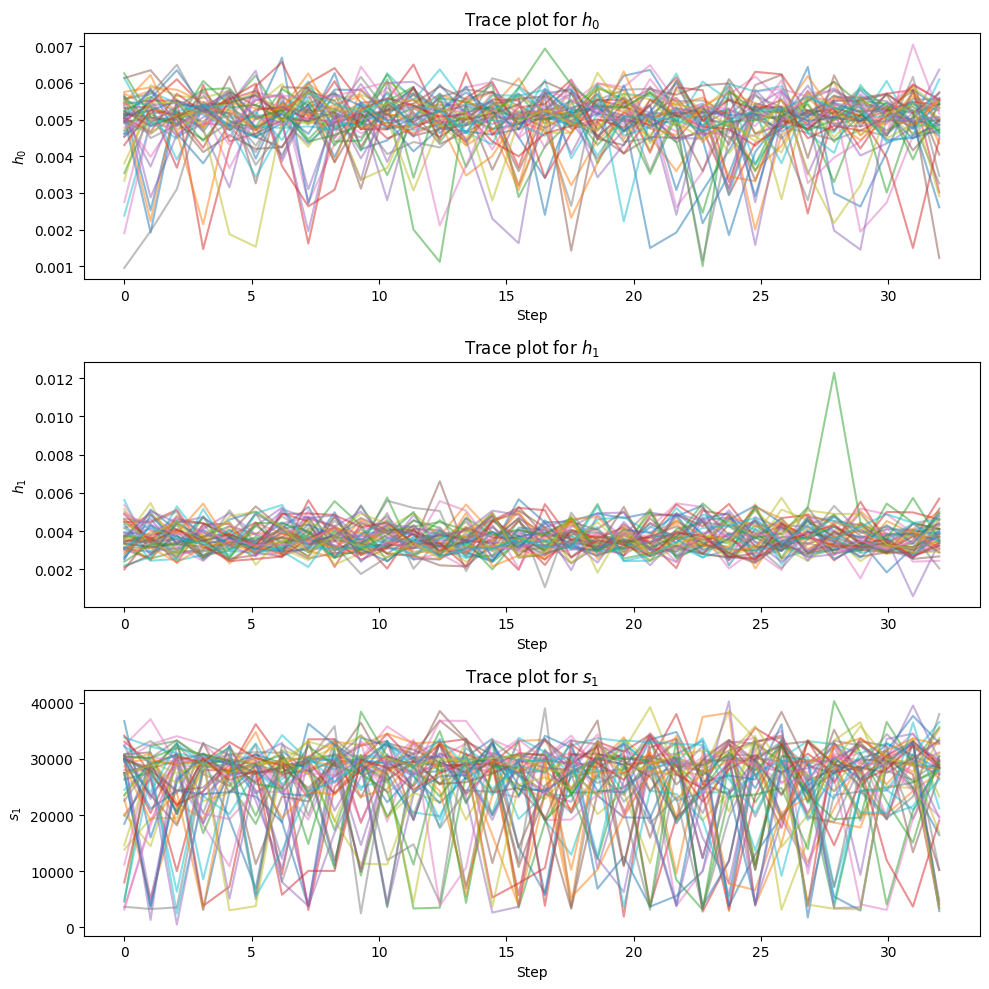

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(10, 10))
steps = np.linspace(0, len(samples), len(samples))
print(np.shape(samples))
for j in range(ndim):
    for i in range(nwalkers):
        ax[j].plot(steps, samples[:, i, j], alpha=0.5)
    ax[j].set_xlabel("Step")
ax[0].set_ylabel(f"$h_0$")
ax[1].set_ylabel(f"$h_1$")
ax[2].set_ylabel(f"$s_1$")
ax[0].set_title(f"Trace plot for $h_0$")
ax[1].set_title(f"Trace plot for $h_1$")
ax[2].set_title(f"Trace plot for $s_1$")

plt.tight_layout()
plt.show()

In [ ]:
# Diagnostics

print("Mean acceptance fraction:", np.mean(sampler.acceptance_fraction))
print("Autocorrelation time:", sampler.get_autocorr_time())

Mean acceptance fraction: 0.489792
Autocorrelation time: [ 63.53328316  74.48512146 139.23171252]


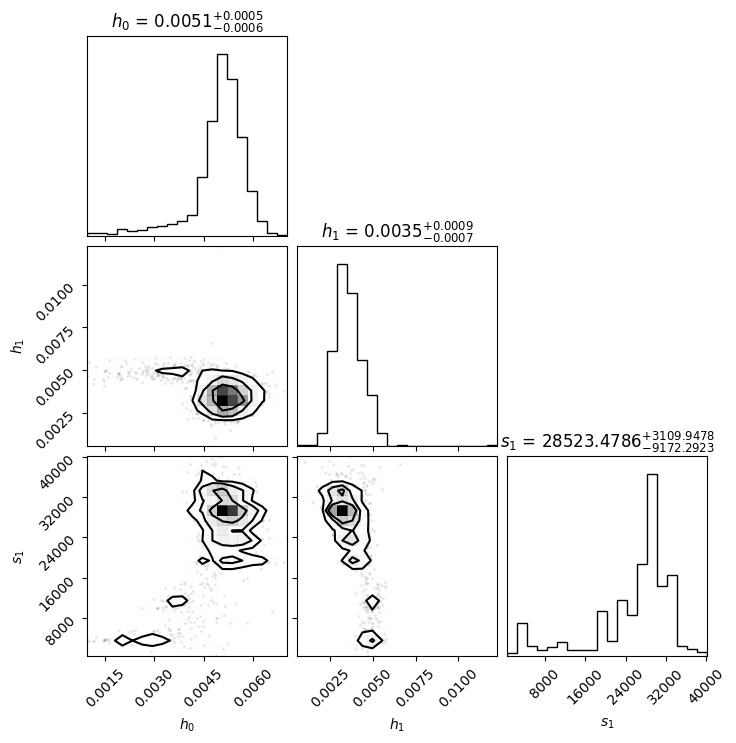

In [ ]:
import corner

flat_samples = sampler.get_chain(discard=1000, thin=thinning_factor, flat=True)
fig = corner.corner(flat_samples, labels=["$h_0$", "$h_1$", "$s_1$"], show_titles=True, title_fmt=".4f")
plt.show()

### (b)

### (c)

### (d)

Here we use `dynesty` to perform nested sampling.

## References

1. [emcee ReadTheDocs](https://emcee.readthedocs.io/en/stable/)
2. [Ensemble samplers with affine invariance (Goodman and Weare)](https://msp.org/camcos/2010/5-1/p04.xhtml)
3. [zeus ReadTheDocs](https://zeus-mcmc.readthedocs.io/en/latest/index.html)
4. [Ensemble slice samplers](https://arxiv.org/pdf/2002.06212)
5. [zeus paper](https://arxiv.org/pdf/2105.03468)